<a href="https://colab.research.google.com/github/immadiBhargavi/pollutionforecast_using-_forum/blob/main/Copy_of_pollutionforecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd# reading dataset

data = pd.read_csv("stations.csv")

print(data.head())

   id station_code       city state_code  pin_code   latitude  longitude  \
0   1         DL01     Dwarka         DL    110078  28.610948  77.038456   
1   2         DL02  New Delhi         DL    110006  28.628191  77.241044   
2   3         DL03      Delhi         DL    110042  28.750815  77.116277   
3   4         CG01    Pawaras         CG    486865  18.388855  81.683361   
4   5         RJ01      Alwar         RJ    356172  27.550006  76.611703   

   elevation_m  topo_complexity  coastal_proximity  valley_factor  
0          215              0.7           0.000000           0.80  
1          212              0.7           0.000000           0.80  
2          217              0.7           0.000000           0.90  
3          212              0.5           0.370772           0.60  
4          286              0.3           0.000000           0.95  


In [ ]:
print(data.columns)#identifying the data columns

Index(['id', 'station_code', 'city', 'state_code', 'pin_code', 'latitude',
       'longitude', 'elevation_m', 'topo_complexity', 'coastal_proximity',
       'valley_factor'],
      dtype='object')


In [ ]:
print(data.info())#info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 553 non-null    int64  
 1   station_code       553 non-null    object 
 2   city               553 non-null    object 
 3   state_code         553 non-null    object 
 4   pin_code           553 non-null    int64  
 5   latitude           553 non-null    float64
 6   longitude          552 non-null    float64
 7   elevation_m        553 non-null    int64  
 8   topo_complexity    553 non-null    float64
 9   coastal_proximity  553 non-null    float64
 10  valley_factor      553 non-null    float64
dtypes: float64(5), int64(3), object(3)
memory usage: 47.7+ KB
None


In [ ]:
data = data.dropna(subset=["latitude","longitude"])# delete latitude and longitude

In [ ]:
import zipfile

with zipfile.ZipFile("city_day.csv.zip","r") as zip_ref:
    zip_ref.extractall()

In [ ]:
import pandas as pd

data = pd.read_csv("city_day.csv")

print(data.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


In [ ]:
data = data.dropna(subset=["PM2.5","PM10","NO2","CO","SO2","AQI"])

In [ ]:
features = ["PM2.5","PM10","NO2","CO","SO2"]
target = "AQI"

X = data[features]
y = data[target]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = RandomForestRegressor()

model.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
stations = pd.read_csv("stations.csv")

stations = stations.dropna(subset=["latitude","longitude"])

In [ ]:
import folium
m = folium.Map(location=[20.5937,78.9629], zoom_start=5)

In [ ]:
import pandas as pd
import requests
import folium

API_KEY = "0a6a93ef0f4daa5f0502664638663b63"

# Read dataset
data = pd.read_csv("stations.csv")

# Remove rows with missing coordinates
data = data.dropna(subset=["latitude", "longitude"])

# AQI color function
def get_color(aqi):
    if aqi == 1:
        return "green"
    elif aqi == 2:
        return "yellow"
    elif aqi == 3:
        return "orange"
    elif aqi == 4:
        return "red"
    else:
        return "purple"

# Create India map
m = folium.Map(location=[22.5, 78.9], zoom_start=5)

# Loop through dataset
for i in range(min(100, len(data))):

    city = data.iloc[i]["city"]
    lat = data.iloc[i]["latitude"]
    lon = data.iloc[i]["longitude"]

    # Get pollution data
    url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={API_KEY}"
    response = requests.get(url).json()

    aqi = response["list"][0]["main"]["aqi"]
    pm25 = response["list"][0]["components"]["pm2_5"]
    pm10 = response["list"][0]["components"]["pm10"]

    color = get_color(aqi)

    # Add marker
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        popup=f"""
        City: {city}<br>
        AQI: {aqi}<br>
        PM2.5: {pm25}<br>
        PM10: {pm10}
        """,
        color=color,
        fill=True,
        fill_color=color
    ).add_to(m)

# Display map
m


In [ ]:
import requests
import folium

# Your OpenWeather API Key
API_KEY = "0a6a93ef0f4daa5f0502664638663b63"


# Function to get city coordinates
def get_coordinates(city):
    url = f"http://api.openweathermap.org/geo/1.0/direct?q={city}&limit=1&appid={API_KEY}"
    response = requests.get(url)
    data = response.json()

    lat = data[0]["lat"]
    lon = data[0]["lon"]

    return lat, lon


# Function to get pollution data
def get_pollution(lat, lon):
    url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={API_KEY}"
    response = requests.get(url)
    data = response.json()

    aqi = data["list"][0]["main"]["aqi"]
    pm25 = data["list"][0]["components"]["pm2_5"]
    pm10 = data["list"][0]["components"]["pm10"]

    return aqi, pm25, pm10


# Function to decide marker color
def get_color(aqi):
    if aqi == 1:
        return "green"
    elif aqi == 2:
        return "yellow"
    elif aqi == 3:
        return "orange"
    elif aqi == 4:
        return "red"
    else:
        return "purple"


# User input
city = "delhi"


# Get coordinates
lat, lon = get_coordinates(city)


# Get pollution values
aqi, pm25, pm10 = get_pollution(lat, lon)


# Print data
print("City:", city)
print("Latitude:", lat)
print("Longitude:", lon)
print("AQI Level:", aqi)
print("PM2.5:", pm25)
print("PM10:", pm10)


# Get color
color = get_color(aqi)


# Create map
m = folium.Map(location=[lat, lon], zoom_start=10)


# Add marker
folium.CircleMarker(
    location=[lat, lon],
    radius=12,
    popup=f"""
    City: {city}<br>
    AQI Level: {aqi}<br>
    PM2.5: {pm25}<br>
    PM10: {pm10}
    """,
    color=color,
    fill=True,
    fill_color=color
).add_to(m)


# Display map
m


City: delhi
Latitude: 28.6138954
Longitude: 77.2090057
AQI Level: 4
PM2.5: 36.66
PM10: 131.9


In [ ]:
import pandas as pd
import requests
import folium
from folium.plugins import HeatMap

API_KEY = "0a6a93ef0f4daa5f0502664638663b63"

# Read dataset
data = pd.read_csv("stations.csv")

# Remove missing coordinates
data = data.dropna(subset=["latitude","longitude"])

heat_data = []

for i in range(min(150, len(data))):

    lat = data.iloc[i]["latitude"]
    lon = data.iloc[i]["longitude"]
    city = data.iloc[i]["city"]

    url = f"http://api.openweathermap.org/data/2.5/air_pollution?lat={lat}&lon={lon}&appid={API_KEY}"
    response = requests.get(url).json()

    aqi = response["list"][0]["main"]["aqi"]

    print(city, "AQI:", aqi)

    # Add to heatmap
    heat_data.append([lat, lon, aqi])

# Create India map
m = folium.Map(location=[22.5,78.9], zoom_start=5)

# Add heatmap
HeatMap(heat_data, radius=15).add_to(m)

# Display map
m


Dwarka AQI: 4
New Delhi AQI: 4
Delhi AQI: 4
Pawaras AQI: 2
Alwar AQI: 4
Bhiwadi AQI: 4
RSPCB AQI: 2
Shrinathgadh AQI: 3
Indira Colony AQI: 5
Jaipur AQI: 4
Udaipur AQI: 3
MPPCB AQI: 2
Manpur AQI: 3
Delhi AQI: 4
Phagwara AQI: 4
Hubballi AQI: 1
Rohtak AQI: 4
Ratanpura AQI: 4
PPCB AQI: 2
Shastri Nagar AQI: 3
Bengaluru South City Corporation AQI: 1
Bengaluru West City Corporation AQI: 1
Rudrapur AQI: 4
Wadgaon Kolhati AQI: 2
PPCB AQI: 4
Jamshedpur AQI: 3
Amritsar AQI: 4
Vikram Nagar AQI: 3
Chennai AQI: 1
Pune AQI: 1
Chennai AQI: 1
Thrissur AQI: 1
Solapur AQI: 1
Nagpur AQI: 2
Nashik AQI: 2
Chennai AQI: 1
Pahari AQI: 4
MPPCB AQI: 2
Tiruchirappalli AQI: 1
HSPCB AQI: 2
HSPCB AQI: 2
Ankleshwar AQI: 2
GPCB AQI: 2
Ahmedabad AQI: 2
Sahilara AQI: 3
Jamnagar AQI: 3
Sagar AQI: 2
Irinjalakuda AQI: 1
Orchha AQI: 3
Chennai AQI: 1
Chennai AQI: 1
Chennai AQI: 1
Chennai AQI: 1
TNPCB AQI: 1
New Delhi AQI: 4
Mumbai AQI: 2
PUNE AQI: 1
Alandi AQI: 1
Pune AQI: 1
Pimpri-Chinchwad AQI: 1
Pune AQI: 1
Jaigaon AQI: 2

In [ ]:
import pandas as pd

# Load dataset
city_aqi_data = pd.read_csv("city_day.csv")

# Show first rows
print("city_aqi_data head:")
display(city_aqi_data.head())

print("\ncity_aqi_data info:")
city_aqi_data.info()

# Get list of cities
unique_cities = city_aqi_data["City"].unique()

print("\nUnique Cities:")
print(unique_cities)


city_aqi_data head:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN



city_aqi_data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB

Unique Cities:
['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopa

In [ ]:
import plotly.express as px

# 1. Directly select the city
selected_city = "Delhi"

# 2. Filter the city_aqi_data DataFrame
city_filtered_data = city_aqi_data[city_aqi_data['City'] == selected_city].copy()

# 3. Define pollutant columns to plot
pollutants_to_plot = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'AQI']

# 4. Convert dataframe to long format
df_melted = city_filtered_data.melt(
    id_vars=['Date'],
    value_vars=pollutants_to_plot,
    var_name='Pollutant',
    value_name='Concentration'
)

# 5. Create interactive line plot
fig = px.line(
    df_melted,
    x='Date',
    y='Concentration',
    color='Pollutant',
    title=f'Time-series of Air Pollutants and AQI in {selected_city}',
    labels={
        'Date': 'Date',
        'Concentration': 'Concentration',
        'Pollutant': 'Pollutant Type'
    },
    hover_data={'Pollutant': True, 'Concentration': ':.2f'}
)

# 6. Show plot
fig.show()


In [ ]:
import plotly.express as px

# 1. Select city directly
selected_city = "Delhi"

# 2. Filter the city_aqi_data DataFrame
city_filtered_data = city_aqi_data[city_aqi_data['City'] == selected_city].copy()

# 3. Define pollutant columns
pollutants_to_plot = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'AQI']

# 4. Convert data to long format
df_melted = city_filtered_data.melt(
    id_vars=['Date'],
    value_vars=pollutants_to_plot,
    var_name='Pollutant',
    value_name='Concentration'
)

# 5. Create line graph
fig = px.line(
    df_melted,
    x='Date',
    y='Concentration',
    color='Pollutant',
    title=f'Time-series of Air Pollutants and AQI in {selected_city}',
    labels={
        'Date': 'Date',
        'Concentration': 'Concentration',
        'Pollutant': 'Pollutant Type'
    },
    hover_data={'Pollutant': True, 'Concentration': ':.2f'}
)

# 6. Show graph
fig.show()


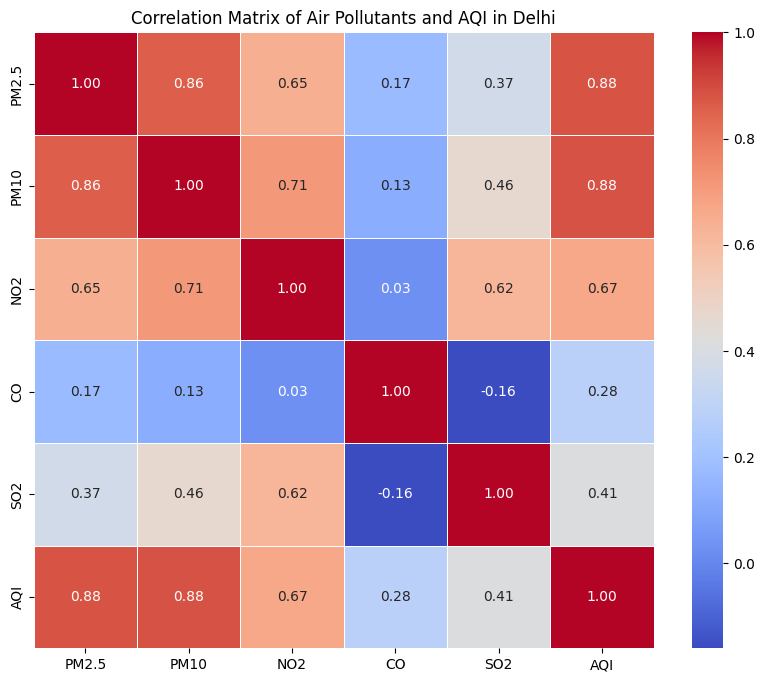

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the relevant columns for correlation analysis
correlation_data = city_filtered_data[pollutants_to_plot].copy()

# 2. Calculate the pairwise correlation matrix
correlation_matrix = correlation_data.corr()

# 3. Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

# 4. Add a title to the heatmap
plt.title(f'Correlation Matrix of Air Pollutants and AQI in {selected_city}')

# 5. Display the plot
plt.show()

In [ ]:
import pandas as pd

# 1. Group by 'City' and calculate the mean of 'AQI'
avg_city_aqi = city_aqi_data.groupby('City')['AQI'].mean().reset_index()

# 2. Reset the index of the avg_city_aqi DataFrame (already done by reset_index() above)

# 3. Convert the 'City' column to title case
avg_city_aqi['City'] = avg_city_aqi['City'].str.title()

print("Average AQI per city with standardized names:")
print(avg_city_aqi.head())

Average AQI per city with standardized names:
        City         AQI
0  Ahmedabad  452.122939
1     Aizawl   34.765766
2  Amaravati   95.299643
3   Amritsar  119.920959
4  Bengaluru   94.318325


In [ ]:
import plotly.express as px

# Sort the DataFrame by AQI for better visualization
avg_city_aqi_sorted = avg_city_aqi.sort_values(by='AQI', ascending=False)

# Create an interactive bar plot
fig = px.bar(
    avg_city_aqi_sorted,
    x='City',
    y='AQI',
    title='Average Air Quality Index (AQI) by City',
    labels={
        'City': 'City',
        'AQI': 'Average AQI'
    },
    hover_data={'City': True, 'AQI': ':.2f'},
    color='AQI', # Color bars by AQI value
    color_continuous_scale=px.colors.sequential.Plasma # Choose a color scale
)

# Update layout for better readability, especially if many cities
fig.update_layout(
    xaxis_tickangle=-45, # Angle x-axis labels to prevent overlap
    height=600 # Adjust plot height
)

# Display the plot
fig.show()

In [ ]:
import pandas as pd

# 1. Convert the 'city' column in the stations DataFrame to title case
stations['city'] = stations['city'].str.title()

# 2. Define a list of relevant geographical features
geographical_features = ['latitude', 'longitude', 'elevation_m', 'topo_complexity', 'coastal_proximity', 'valley_factor']

# 3. Create a new DataFrame, geo_features, containing only the 'city' column and the selected geographical features
geo_features = stations[['city'] + geographical_features].copy()

# 4. Display the first few rows of the geo_features DataFrame
print("Geo Features with standardized city names:")
print(geo_features.head())

Geo Features with standardized city names:
        city   latitude  longitude  elevation_m  topo_complexity  \
0     Dwarka  28.610948  77.038456          215              0.7   
1  New Delhi  28.628191  77.241044          212              0.7   
2      Delhi  28.750815  77.116277          217              0.7   
3    Pawaras  18.388855  81.683361          212              0.5   
4      Alwar  27.550006  76.611703          286              0.3   

   coastal_proximity  valley_factor  
0           0.000000           0.80  
1           0.000000           0.80  
2           0.000000           0.90  
3           0.370772           0.60  
4           0.000000           0.95  


In [ ]:
import plotly.express as px

# 1. Prompt the user to enter a city name
selected_city = "Delhi"

# 2. Filter the city_aqi_data DataFrame
city_filtered_data = city_aqi_data[city_aqi_data['City'] == selected_city].copy()

# 3. Define a list of pollutant columns to be plotted
pollutants_to_plot = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'AQI']

# 4. Melt the city_filtered_data DataFrame to long format
df_melted = city_filtered_data.melt(
    id_vars=['Date'],
    value_vars=pollutants_to_plot,
    var_name='Pollutant',
    value_name='Concentration'
)

# 5. Create an interactive line plot using px.line()
fig = px.line(
    df_melted,
    x='Date',
    y='Concentration',
    color='Pollutant',
    title=f'Time-series of Air Pollutants and AQI in {selected_city}',
    labels={
        'Date': 'Date',
        'Concentration': 'Concentration',
        'Pollutant': 'Pollutant Type'
    },
    hover_data={'Pollutant': True, 'Concentration': ':.2f'}
)

# 6. Display the plot
fig.show()


In [ ]:
import pandas as pd

# 2. Load the `city_day.csv` file into a DataFrame named `city_aqi_data`.
city_aqi_data = pd.read_csv("city_day.csv")

# 3. Convert the 'Date' column in `city_aqi_data` to datetime objects.
city_aqi_data['Date'] = pd.to_datetime(city_aqi_data['Date'])

# 4. Drop rows from `city_aqi_data` where any of the specified columns have missing values.
# Note: The previous notebook used a different dataframe named 'data' for dropping NA values.
# This step ensures 'city_aqi_data' is prepared correctly as per the subtask instructions.
city_aqi_data = city_aqi_data.dropna(subset=["PM2.5","PM10","NO2","CO","SO2","AQI"])

# 5. Extract all unique city names and store them in a list called `unique_cities`.
unique_cities = city_aqi_data['City'].unique().tolist()

# 6. Print the first few rows of `city_aqi_data` and display its information using `.info()`.
print("city_aqi_data head:")
display(city_aqi_data.head())

print("\ncity_aqi_data info:")
city_aqi_data.info()

# 7. Print the list of `unique_cities`.
print("\nUnique Cities:")
print(unique_cities)

city_aqi_data head:


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
1595,Ahmedabad,2019-05-15,37.55,122.41,15.08,85.12,58.72,NaN,15.08,163.01,48.23,16.44,85.54,14.19,281.0,Poor
1596,Ahmedabad,2019-05-16,33.97,116.32,14.67,79.71,55.61,NaN,14.67,91.26,51.86,15.55,83.89,13.15,330.0,Very Poor
1597,Ahmedabad,2019-05-17,35.48,130.07,18.02,77.61,58.41,NaN,18.02,98.35,38.99,15.88,83.83,13.34,356.0,Very Poor
1598,Ahmedabad,2019-05-18,34.11,138.31,13.27,75.23,51.83,NaN,13.27,88.66,42.22,15.93,82.73,13.44,359.0,Very Poor
1599,Ahmedabad,2019-05-19,33.69,111.73,34.56,68.90,69.77,NaN,34.56,80.90,36.95,15.53,84.17,13.19,547.0,Severe



city_aqi_data info:
<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 1595 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        16291 non-null  object        
 1   Date        16291 non-null  datetime64[ns]
 2   PM2.5       16291 non-null  float64       
 3   PM10        16291 non-null  float64       
 4   NO          16184 non-null  float64       
 5   NO2         16291 non-null  float64       
 6   NOx         15846 non-null  float64       
 7   NH3         14665 non-null  float64       
 8   CO          16291 non-null  float64       
 9   SO2         16291 non-null  float64       
 10  O3          16010 non-null  float64       
 11  Benzene     14258 non-null  float64       
 12  Toluene     12223 non-null  float64       
 13  Xylene      6787 non-null   float64       
 14  AQI         16291 non-null  float64       
 15  AQI_Bucket  16291 non-null  object        
dtypes: 